# Offline Analysis and Visualization

Summarize offline motor-imagery runs (scratch vs transfer vs classical), plot metrics, and generate confusion matrices from saved models. Headless-safe.

**Paths (adjust if needed):**
- Data: `experiment/data/sub-01_run-XX_online_raw.fif`
- Metrics CSV: `experiment/results/offline_metrics.csv`
- Models: `experiment/models/`
- Plots/output: `experiment/results/`


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import mne

# Headless safe for psychopy/pyglet if imported indirectly
os.environ.setdefault('PYGLET_HEADLESS', 'True')

# Inline plots
%matplotlib inline
sns.set_context('notebook')

# ------------------------ repo-relative paths ------------------------

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

REPO_ROOT = find_repo_root(Path.cwd().resolve())

DATA_DIR = REPO_ROOT / "data" / "self"
RESULTS_DIR = REPO_ROOT / "runs" / "self" / "results"
MODELS_DIR = REPO_ROOT / "runs" / "self" / "models"
METRICS_CSV = RESULTS_DIR / "offline_metrics.csv"

# Add module paths (so this notebook runs without requiring installation)
sys.path.insert(0, str(REPO_ROOT / "apps" / "headset_frontend" / "src"))
sys.path.insert(0, str(REPO_ROOT / "pipeline" / "src"))
# The public pipeline modules use script-style imports (e.g. `import data_utils`)
sys.path.insert(0, str(REPO_ROOT / "pipeline" / "src" / "pipeline" / "public"))

from headset_frontend.online_preprocessing import preprocess_epoch_data
from headset_frontend.online_mi_pipeline import EPOCH_TMIN, EPOCH_TMAX
from hybrid_cnn_transformer import HybridModelClassifier
from feature_modules import CSPModule


In [2]:
# Load metrics and parse fields from `notes`
import re


def load_metrics(path=METRICS_CSV):
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError('Metrics CSV is empty')
    return df


def parse_runs(notes: str):
    """Parse runs=[...] from notes; returns list like ['01','02',...]."""
    m = re.search(r"runs=\[(.*?)\]", str(notes))
    if not m:
        return []
    run_list = m.group(1).replace("'", "").split(',')
    return [r.strip() for r in run_list if r.strip()]


def parse_run_list_field(notes: str, key: str):
    """Parse key=[...] from notes; returns list of strings like ['01','02',...]."""
    m = re.search(fr"{re.escape(key)}=\[(.*?)\]", str(notes))
    if not m:
        return []
    items = m.group(1).replace("'", "").split(',')
    return [x.strip() for x in items if x.strip()]


def parse_str_field(notes: str, key: str):
    """Parse key=value (non-; sequence) from notes."""
    m = re.search(fr"{re.escape(key)}=([^;]+)", str(notes))
    return m.group(1).strip() if m else None


def parse_int_field(notes: str, key: str):
    m = re.search(fr"{re.escape(key)}=(\d+)", str(notes))
    return int(m.group(1)) if m else None


def parse_float_field(notes: str, key: str):
    m = re.search(fr"{re.escape(key)}=([0-9]*\.?[0-9]+)", str(notes))
    return float(m.group(1)) if m else None


def is_prefix_01_to_k(runs_list):
    """True if runs_list is exactly ['01','02',...,'0k'] (order-insensitive)."""
    if not runs_list:
        return False
    try:
        ints = sorted(int(r) for r in runs_list)
    except Exception:
        return False
    return ints == list(range(1, len(ints) + 1))


df = load_metrics()

# Derived fields
_df_runs = df['notes'].apply(parse_runs)
df['runs_list'] = _df_runs

df['n_runs'] = df['runs_list'].apply(len)
df['runs_key'] = df['runs_list'].apply(lambda rs: ','.join(rs))
df['csp_components'] = df['notes'].apply(lambda s: parse_int_field(s, 'csp_components'))
df['target_channels'] = df['notes'].apply(lambda s: parse_int_field(s, 'target_channels'))
df['seed'] = df['notes'].apply(lambda s: parse_int_field(s, 'seed'))
df['val_split'] = df['notes'].apply(lambda s: parse_float_field(s, 'val_split'))

# New: run-wise split tags
# - split: random_stratified / leave_one_run_out / holdout_run / explicit_runs
# - train_runs=[...]
# - test_run=03 (preferred) or test_runs=[...]
df['split'] = df['notes'].apply(lambda s: parse_str_field(s, 'split') or 'random_stratified')
df['train_runs'] = df['notes'].apply(lambda s: parse_run_list_field(s, 'train_runs'))
df['test_run'] = df['notes'].apply(lambda s: parse_str_field(s, 'test_run'))
df['test_runs'] = df['notes'].apply(lambda s: parse_run_list_field(s, 'test_runs'))
df['metric_name'] = df['notes'].apply(lambda s: parse_str_field(s, 'metric'))

# Keep legacy prefix logic (only meaningful for random-split run subsets)
df['is_prefix_01_to_k'] = df['runs_list'].apply(is_prefix_01_to_k)

# A conservative grouping key (won't combine apples/oranges)
# Include split + explicit test_run where present so run-wise results never mix with random splits.
df['group_key'] = df.apply(
    lambda r: (
        f"{r['mode']}|base={Path(str(r['base_model'])).name if pd.notnull(r['base_model']) else ''}"
        f"|csp={r['csp_components']}|tc={r['target_channels']}"
        f"|split={r['split']}"
        + (f"|test_run={r['test_run']}" if pd.notnull(r['test_run']) and str(r['test_run']) else "")
        + (f"|train_runs={','.join(r['train_runs'])}" if isinstance(r['train_runs'], list) and len(r['train_runs']) > 0 else "")
        + (f"|runs={r['runs_key']}" if pd.notnull(r['runs_key']) else "")
    ),
    axis=1,
)

df

,timestamp,mode,base_model,subjects,trials,val_accuracy,notes,runs_list,n_runs,runs_key,...,target_channels,seed,val_split,split,train_runs,test_run,test_runs,metric_name,is_prefix_01_to_k,group_key
0,2025-12-11T05:58:18.369320,scratch,NaN,1,773,0.567742,"csp_components=6;runs=['01', '02', '03', '04',...","[01, 02, 03, 04, 05, 06, 07, 08]",8,"01,02,03,04,05,06,07,08",...,NaN,NaN,NaN,random_stratified,[],None,[],None,True,scratch|base=|csp=6|tc=nan|split=random_strati...
1,2025-12-11T06:20:15.711521,transfer,../model/models/base_model_90_subjects.pt,1,773,0.638710,"csp_components=6;runs=['01', '02', '03', '04',...","[01, 02, 03, 04, 05, 06, 07, 08]",8,"01,02,03,04,05,06,07,08",...,14.0,NaN,NaN,random_stratified,[],None,[],None,True,transfer|base=base_model_90_subjects.pt|csp=6|...
2,2025-12-11T06:24:40.262953,transfer,../model/models/base_model_90_subjects.pt,1,773,0.651613,"csp_components=6;runs=['01', '02', '03', '04',...","[01, 02, 03, 04, 05, 06, 07, 08]",8,"01,02,03,04,05,06,07,08",...,14.0,NaN,NaN,random_stratified,[],None,[],None,True,transfer|base=base_model_90_subjects.pt|csp=6|...
3,2025-12-11T18:26:26.477744,scratch,NaN,1,189,0.605263,"csp_components=6;runs=['01', '02'];target_chan...","[01, 02]",2,"01,02",...,16.0,NaN,NaN,random_stratified,[],None,[],None,True,scratch|base=|csp=6|tc=16.0|split=random_strat...
4,2025-12-11T18:26:41.015805,transfer,/home/connor/LIINC/model/models/base_model_90_...,1,189,0.736842,"csp_components=6;runs=['01', '02'];target_chan...","[01, 02]",2,"01,02",...,14.0,NaN,NaN,random_stratified,[],None,[],None,True,transfer|base=base_model_90_subjects.pt|csp=6|...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2025-12-11T20:05:51.311258,transfer,/home/connor/LIINC/model/models/base_model_90_...,1,773,0.684211,"csp_components=6;runs=['01', '02', '03', '04',...","[01, 02, 03, 04, 05, 06, 07, 08]",8,"01,02,03,04,05,06,07,08",...,14.0,0.0,0.0,0.0,"[01, 02, 03, 04, 05, 06, 07]",08,[],val_accuracy,True,transfer|base=base_model_90_subjects.pt|csp=6|...
60,2025-12-11T20:05:57.799607,ts_lr,NaN,1,800,0.740000,"csp_components=6;runs=['01', '02', '03', '04',...","[01, 02, 03, 04, 05, 06, 07, 08]",8,"01,02,03,04,05,06,07,08",...,NaN,0.0,0.0,0.0,"[01, 02, 03, 04, 05, 06, 07]",08,[],val_accuracy,True,ts_lr|base=|csp=6|tc=nan|split=0.0|test_run=08...
61,2025-12-11T20:06:06.846222,scratch,NaN,1,481,0.602041,"csp_components=6;runs=['01', '02', '03', '04',...","[01, 02, 03, 04, 05]",5,"01,02,03,04,05",...,16.0,0.0,0.0,0.0,"[01, 02, 03, 04]",05,[],val_accuracy,True,scratch|base=|csp=6|tc=16.0|split=0.0|test_run...
62,2025-12-11T20:06:18.554447,transfer,/home/connor/LIINC/model/models/base_model_90_...,1,481,0.622449,"csp_components=6;runs=['01', '02', '03', '04',...","[01, 02, 03, 04, 05]",5,"01,02,03,04,05",...,14.0,0.0,0.0,0.0,"[01, 02, 03, 04]",05,[],val_accuracy,True,transfer|base=base_model_90_subjects.pt|csp=6|...


In [3]:
# Summaries (don't over-combine): group by mode + run-set + base model + key hyperparams

# NOTE: exclude run-wise splits here; those are plotted in the dedicated run-wise section.

df_rand = df[df['split'] == 'random_stratified'].copy()

summary = (
    df_rand.groupby(['mode', 'base_model', 'n_runs', 'runs_key', 'csp_components', 'target_channels'])
      .agg(
          count=('val_accuracy', 'size'),
          mean_val_acc=('val_accuracy', 'mean'),
          std_val_acc=('val_accuracy', 'std'),
          min_val_acc=('val_accuracy', 'min'),
          max_val_acc=('val_accuracy', 'max'),
      )
      .reset_index()
      .sort_values(['mode', 'n_runs', 'runs_key'])
)

summary

,mode,base_model,n_runs,runs_key,csp_components,target_channels,count,mean_val_acc,std_val_acc,min_val_acc,max_val_acc
1,transfer,/home/connor/LIINC/model/models/base_model_90_...,2,"01,02",6,14.0,6,0.741228,0.019810,0.710526,0.763158
2,transfer,/home/connor/LIINC/model/models/base_model_90_...,4,"01,02,03,04",6,14.0,6,0.653680,0.031456,0.623377,0.714286
0,transfer,../model/models/base_model_90_subjects.pt,8,"01,02,03,04,05,06,07,08",6,14.0,2,0.645161,0.009124,0.638710,0.651613
3,transfer,/home/connor/LIINC/model/models/base_model_90_...,8,"01,02,03,04,05,06,07,08",6,14.0,5,0.607742,0.027899,0.574194,0.638710


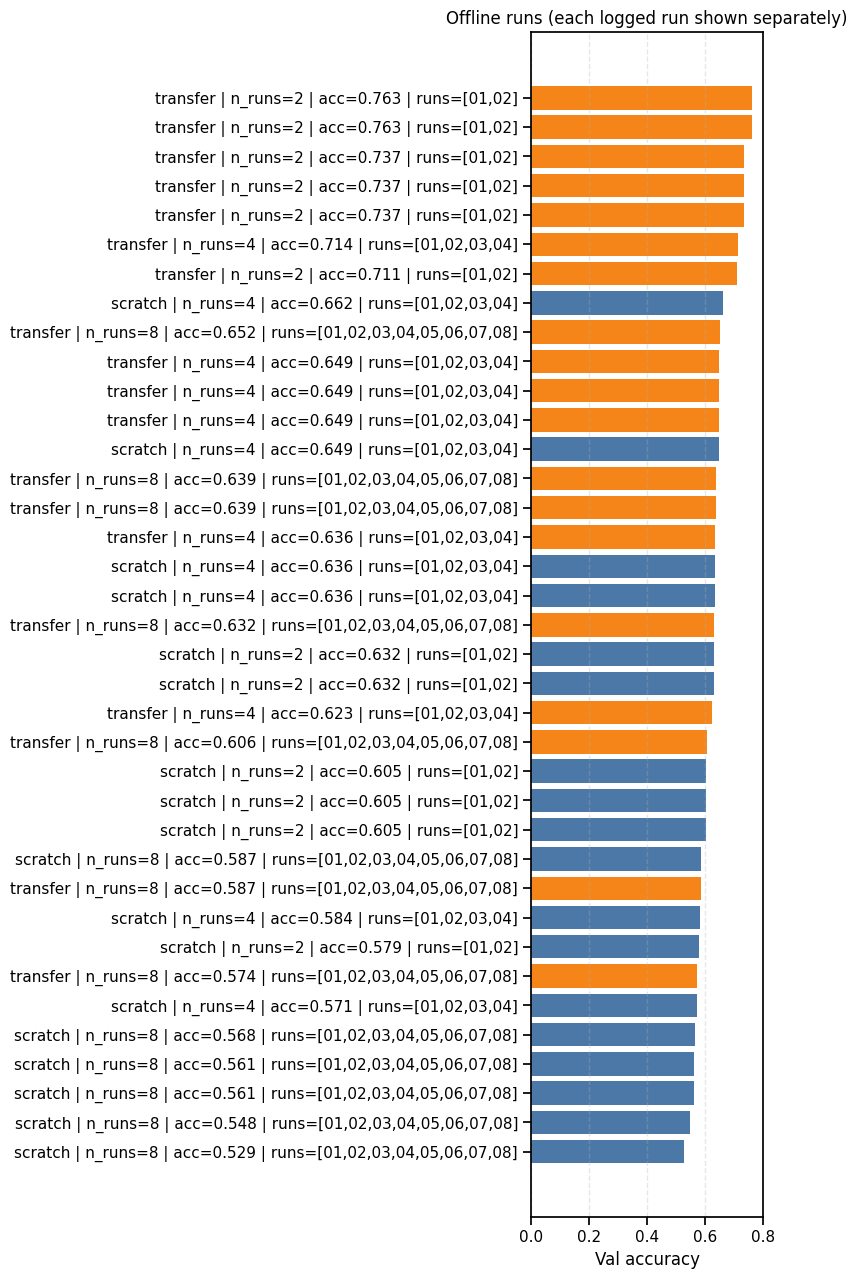

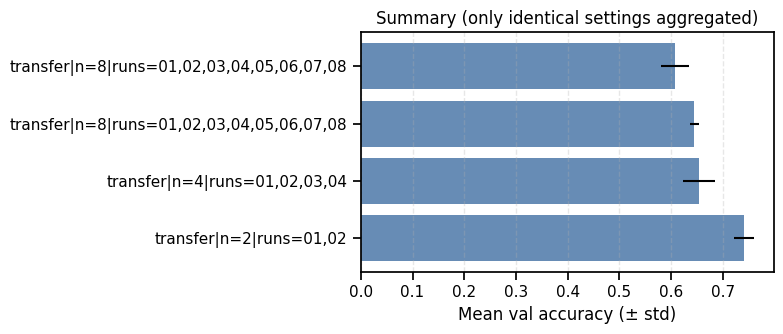

In [4]:
# Per-run bar plot (each row) + conservative summary view
# NOTE: exclude run-wise splits here; those are plotted in the dedicated run-wise section.

df_rand = df[df['split'] == 'random_stratified'].copy()

colors = {'scratch': '#4c78a8', 'transfer': '#f58518', 'ts_lr': '#72b7b2'}

# Per-run plot: every logged run is distinct
fig, ax = plt.subplots(figsize=(8, max(3.5, 0.35 * len(df_rand))))
df_sorted = df_rand.sort_values('val_accuracy', ascending=True).reset_index(drop=True)
ax.barh(
    range(len(df_sorted)),
    df_sorted['val_accuracy'],
    color=[colors.get(m, '#72b7b2') for m in df_sorted['mode']]
)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels([
    f"{row.mode} | n_runs={row.n_runs} | acc={row.val_accuracy:.3f} | runs=[{row.runs_key}]"
    for row in df_sorted.itertuples(index=False)
])
ax.set_xlabel('Val accuracy')
ax.set_title('Offline runs (each logged run shown separately)')
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table is already shown in the previous cell; here is a compact plot of mean acc by n_runs per mode.
# IMPORTANT: This aggregates ONLY identical (mode, base_model, runs_key, csp_components, target_channels).
compact = summary.copy()
compact['label'] = compact.apply(lambda r: f"{r['mode']}|n={int(r['n_runs'])}|runs={r['runs_key']}", axis=1)

fig, ax = plt.subplots(figsize=(8, max(3.5, 0.35 * len(compact))))
ax.barh(range(len(compact)), compact['mean_val_acc'], xerr=compact['std_val_acc'].fillna(0.0), color='#4c78a8', alpha=0.85)
ax.set_yticks(range(len(compact)))
ax.set_yticklabels(compact['label'])
ax.set_xlabel('Mean val accuracy (± std)')
ax.set_title('Summary (only identical settings aggregated)')
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


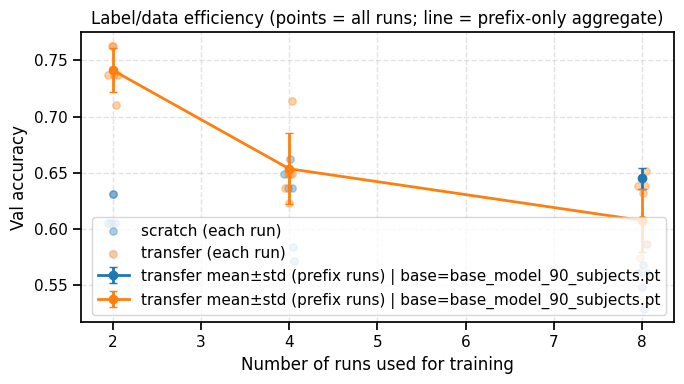

,mode,base_model,n_runs,mean_acc,std_acc,n
0,transfer,../model/models/base_model_90_subjects.pt,8,0.645161,0.009124,2
1,transfer,/home/connor/LIINC/model/models/base_model_90_...,2,0.741228,0.019810,6
2,transfer,/home/connor/LIINC/model/models/base_model_90_...,4,0.653680,0.031456,6
3,transfer,/home/connor/LIINC/model/models/base_model_90_...,8,0.607742,0.027899,5


In [5]:
# Learning curve: show *all points* + a conservative aggregated curve
# We avoid combining runs that aren't directly comparable.
# NOTE: exclude run-wise splits here; those are plotted in the dedicated run-wise section.

df_rand = df[df['split'] == 'random_stratified'].copy()

fig, ax = plt.subplots(figsize=(7, 4))
rng = np.random.RandomState(0)

# Scatter: every run as a point (colored by mode)
for mode, sub in df_rand.groupby('mode'):
    x = sub['n_runs'].to_numpy(dtype=float)
    y = sub['val_accuracy'].to_numpy(dtype=float)
    jitter = (rng.rand(len(x)) - 0.5) * 0.12
    ax.scatter(x + jitter, y, alpha=0.35, s=28, label=f"{mode} (each run)")

# Conservative curve: only for the canonical '01..k' prefix run-sets
prefix_df = df_rand[df_rand['is_prefix_01_to_k']].copy()

# Sanity check: if multiple different run-sets exist for the same n_runs in prefix_df, warn and do NOT aggregate.
ambiguous = (
    prefix_df.groupby(['mode', 'base_model', 'n_runs'])['runs_key']
             .nunique()
             .reset_index(name='n_unique_runsets')
)
ambiguous = ambiguous[ambiguous['n_unique_runsets'] > 1]
if len(ambiguous) > 0:
    print('WARNING: multiple run-sets for same n_runs; skipping aggregated prefix curve for these groups:')
    display(ambiguous)

# Aggregate only when unambiguous
ok_groups = set(
    tuple(r) for r in (
        prefix_df.groupby(['mode', 'base_model', 'n_runs'])['runs_key'].nunique().reset_index().query('runs_key == 1')[['mode','base_model','n_runs']].itertuples(index=False, name=None)
    )
)

prefix_df['ok_group'] = prefix_df.apply(lambda r: (r['mode'], r['base_model'], r['n_runs']) in ok_groups, axis=1)
plot_df = prefix_df[prefix_df['ok_group']].copy()

agg = (
    plot_df.groupby(['mode', 'base_model', 'n_runs'])
           .agg(mean_acc=('val_accuracy', 'mean'), std_acc=('val_accuracy', 'std'), n=('val_accuracy', 'size'))
           .reset_index()
)

for (mode, base_model), sub in agg.groupby(['mode', 'base_model']):
    sub = sub.sort_values('n_runs')
    label = f"{mode} mean±std (prefix runs)" + (f" | base={Path(str(base_model)).name}" if pd.notnull(base_model) and str(base_model) else "")
    ax.errorbar(sub['n_runs'], sub['mean_acc'], yerr=sub['std_acc'], marker='o', capsize=3, linewidth=2, label=label)

ax.set_xlabel('Number of runs used for training')
ax.set_ylabel('Val accuracy')
ax.set_title('Label/data efficiency (points = all runs; line = prefix-only aggregate)')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Table view of the prefix aggregation
agg.sort_values(['mode','base_model','n_runs'])

In [6]:
# Helpers to load data, align channels, and evaluate a saved model with confusion matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def load_runs(subject='01', runs=None, data_dir=DATA_DIR):
    """Load runs into (X, y) plus per-trial run_id labels."""
    if runs is None:
        runs = sorted([p.name.split('_')[1].split('-')[1] for p in data_dir.glob(f'sub-{subject}_run-*_online_raw.fif')])
    raw_data = []
    run_ids = []
    for run in runs:
        path = data_dir / f'sub-{subject}_run-{int(run):02d}_online_raw.fif'
        if not path.exists():
            continue
        raw = mne.io.read_raw_fif(str(path), preload=True, verbose=False)
        events = mne.find_events(raw, stim_channel='STI 014', shortest_event=1)
        X_run, y_run = preprocess_epoch_data(raw, events, EPOCH_TMIN, EPOCH_TMAX)
        y_run = y_run - 1  # 1/2 -> 0/1
        raw_data.append((X_run, y_run))
        run_ids.append(np.full(len(y_run), int(run), dtype=int))
    if not raw_data:
        raise ValueError('No data loaded; check paths/runs')
    n_times_list = [d[0].shape[2] for d in raw_data]
    common_length = (min(n_times_list) // 32) * 32
    X = np.concatenate([d[0][:, :, :common_length] for d in raw_data], axis=0)
    y = np.concatenate([d[1] for d in raw_data], axis=0)
    run_id = np.concatenate(run_ids, axis=0)
    idx = np.zeros(len(y), dtype=int)  # single subject
    return X, y, idx, common_length, run_id


def match_channels(x: torch.Tensor, target_channels: int):
    if x.size(1) == target_channels:
        return x
    if x.size(1) < target_channels:
        pad = torch.zeros(x.size(0), target_channels - x.size(1), x.size(2), device=x.device, dtype=x.dtype)
        return torch.cat([x, pad], dim=1)
    return x[:, :target_channels, :]


def evaluate_model(model_path, runs, subject='01', val_split=0.2, seed=42):
    X, y, idx, common_length, run_id = load_runs(subject=subject, runs=runs)
    X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
        X, y, idx, test_size=val_split, stratify=y, random_state=seed
    )
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.long, device=device)
    idx_val_t = torch.tensor(idx_val, dtype=torch.long, device=device)

    clf, metadata = HybridModelClassifier.load_model(str(model_path), device=device)
    target_channels = getattr(clf.model, 'n_channels', X_val_t.shape[1])
    X_val_t = match_channels(X_val_t, target_channels)

    # For evaluation we disable feature_modules if missing; otherwise use saved modules
    if hasattr(clf, 'feature_modules') and clf.feature_modules:
        pass
    else:
        clf.use_feature_modules = False

    res = clf.evaluate(X_val_t, y_val_t, subject_indices=idx_val_t)
    cm = confusion_matrix(res['targets'], res['predictions'])
    return res['accuracy'], cm


def plot_cm(cm, title):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.tight_layout()
    plt.show()


Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 3 epochs: 0, 3, 87
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 5 epochs: 32, 44, 52, 58, 82
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 3 epochs: 24, 48, 69
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 3 epochs: 74, 75, 91
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 2 epochs: 4, 62
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 3 epochs: 0, 47, 89
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 1 epoch: 0
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 6 epochs: 0, 1, 3, 5, 7, 37
scratch acc: 0.5548


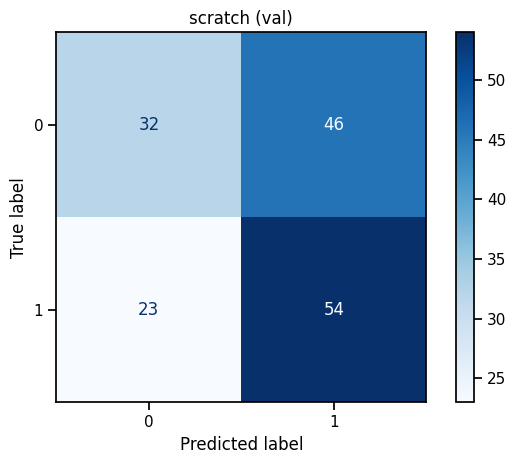

Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 3 epochs: 0, 3, 87
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 5 epochs: 32, 44, 52, 58, 82
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 3 epochs: 24, 48, 69
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 3 epochs: 74, 75, 91
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 2 epochs: 4, 62
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 3 epochs: 0, 47, 89
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 1 epoch: 0
Finding events on: STI 014
100 events found on stim channel STI 014
Event IDs: [1 2]
Dropped 6 epochs: 0, 1, 3, 5, 7, 37
transfer acc: 0.6387


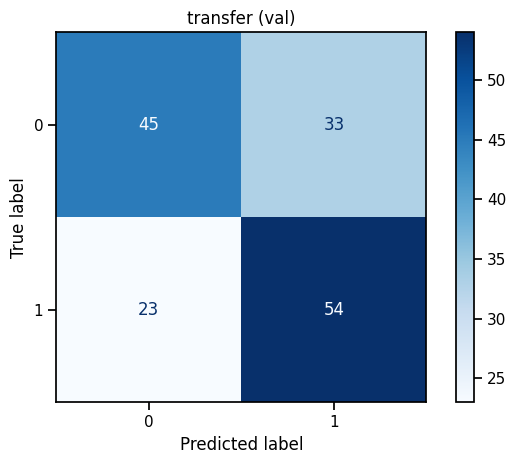

{'scratch': {'acc': 0.5548387096774193,
  'cm': array([[32, 46],
         [23, 54]])},
 'transfer': {'acc': 0.6387096774193548,
  'cm': array([[45, 33],
         [23, 54]])}}

In [7]:
# Evaluate best scratch and transfer models and show confusion matrices (adjust paths if needed)
SCRATCH_MODEL = MODELS_DIR / 'offline_scratch' / 'offline_scratch.pt'
TRANSFER_MODEL = MODELS_DIR / 'offline_transfer' / 'offline_transfer.pt'
RUNS = ['01','02','03','04','05','06','07','08']

results = {}
for name, path in [('scratch', SCRATCH_MODEL), ('transfer', TRANSFER_MODEL)]:
    if path.exists():
        acc, cm = evaluate_model(path, RUNS)
        results[name] = {'acc': acc, 'cm': cm}
        print(f"{name} acc: {acc:.4f}")
        plot_cm(cm, f"{name} (val)")
    else:
        print(f"Missing model: {path}")

results

## Optional: run extra label-efficiency sweeps (2- and 4-run subsets)

Set `RUN_SWEEP = True` in the next cell to automatically launch additional training jobs (scratch + transfer) on smaller run subsets (e.g., runs 01–02 and 01–04). This appends results to `results/offline_metrics.csv` and reuses your base model at `../model/models/base_model_90_subjects.pt`.

In [8]:
import subprocess, shlex

RUN_SWEEP = False  # set True to launch jobs
BASE_MODEL = REPO_ROOT / "legacy" / "model" / "models" / "base_model_90_subjects.pt"
RUN_SETS = [
    ['01', '02'],
    ['01', '02', '03', '04'],
]

cmds = []
for runs in RUN_SETS:
    run_str = ' '.join(runs)
    # scratch
    cmds.append(
        f"python -m pipeline.self.train --data-dir data/self --runs {run_str} "
        f"--model-name offline_scratch_r{len(runs)} --output-dir runs/self/models/offline_scratch_r{len(runs)} "
        f"--metrics-csv runs/self/results/offline_metrics.csv"
    )
    # transfer
    cmds.append(
        f"python -m pipeline.self.train --data-dir data/self --runs {run_str} "
        f"--base-model-path {BASE_MODEL} "
        f"--model-name offline_transfer_r{len(runs)} --output-dir runs/self/models/offline_transfer_r{len(runs)} "
        f"--metrics-csv runs/self/results/offline_metrics.csv"
    )

print("Planned commands (set RUN_SWEEP=True to execute):\n")
for c in cmds:
    print(c)

if RUN_SWEEP:
    for c in cmds:
        print(f"\nRunning: {c}")
        proc = subprocess.run(shlex.split(c), cwd=REPO_ROOT, env={**os.environ, 'PYGLET_HEADLESS': 'True'})
        if proc.returncode != 0:
            print(f"Command failed: {c}")
            break


Planned commands (set RUN_SWEEP=True to execute):

python -m pipeline.self.train --data-dir data/self --runs 01 02 --model-name offline_scratch_r2 --output-dir runs/self/models/offline_scratch_r2 --metrics-csv runs/self/results/offline_metrics.csv
python -m pipeline.self.train --data-dir data/self --runs 01 02 --base-model-path /home/connor/LIINC/eeg-motor-classification/legacy/model/models/base_model_90_subjects.pt --model-name offline_transfer_r2 --output-dir runs/self/models/offline_transfer_r2 --metrics-csv runs/self/results/offline_metrics.csv
python -m pipeline.self.train --data-dir data/self --runs 01 02 03 04 --model-name offline_scratch_r4 --output-dir runs/self/models/offline_scratch_r4 --metrics-csv runs/self/results/offline_metrics.csv
python -m pipeline.self.train --data-dir data/self --runs 01 02 03 04 --base-model-path /home/connor/LIINC/eeg-motor-classification/legacy/model/models/base_model_90_subjects.pt --model-name offline_transfer_r4 --output-dir runs/self/models/o

## Run-wise generalization (stronger than random splits)

This evaluates **session/run drift** by training on some runs and testing on held-out runs.

- **LORO**: leave-one-run-out (train on all-but-one run; test on the held-out run)
- **Holdout**: train on runs `01..k` and test on run `k+1` (or a chosen test run)

All results append to `results/offline_metrics.csv` with clear `notes` tags (e.g. `split=leave_one_run_out`, `train_runs=[...]`, `test_run=03`) so they **won’t be aggregated with random-split results**.


In [9]:
# Run-wise experiments (no terminal): deep scratch vs transfer vs TS+LR
from datetime import datetime

from pipeline.self.train_offline_model import train_and_eval_on_runs
from pipeline.self.mi_riemann_probe import load_epochs_for_subject, ts_lr_runwise_accuracy

RUN_RUNWISE = False  # set True to run (can be ~5-15 min depending on epochs)

RUNWISE_SUBJECT = '01'
RUNWISE_RUNS = ['01','02','03','04','05','06','07','08']
BASE_MODEL = REPO_ROOT / "legacy" / "model" / "models" / "base_model_90_subjects.pt"

# Runtime knobs
RUNWISE_EPOCHS_SCRATCH = 70
RUNWISE_EPOCHS_TRANSFER = 50
RUNWISE_BATCH_SIZE = 32
RUNWISE_LR = 1e-4
RUNWISE_WEIGHT_DECAY = 1e-5
RUNWISE_DROPOUT = 0.1
RUNWISE_CSP_COMPONENTS = 6

# Classical baseline window (keep aligned with typical MI window)
TSLR_TMIN = 0.5
TSLR_TMAX = 2.0
TSLR_USE_CSD = True
TSLR_COV_EST = 'lwf'

# Output locations
RUNWISE_MODELS_DIR = MODELS_DIR / 'runwise'


def _run_file_exists(subject, run_id):
    return (DATA_DIR / f"sub-{subject}_run-{int(run_id):02d}_online_raw.fif").exists()


def _ensure_runs_exist(subject, runs):
    missing = [r for r in runs if not _run_file_exists(subject, r)]
    if missing:
        raise FileNotFoundError(f"Missing FIF runs for subject={subject}: {missing}")


def _append_runwise_summary_row(split_tag: str, mode: str, base_model: str, accs_by_run: dict):
    """Optional: write a summary row; we keep per-run rows as the primary record."""
    pass


def run_loro(subject: str, runs: list[str], *, seed: int = 0, max_epochs_scratch: int = 70, max_epochs_transfer: int = 50):
    """Leave-one-run-out. Returns a DataFrame with per-run accuracies (scratch/transfer/ts_lr)."""
    _ensure_runs_exist(subject, runs)

    rows = []
    for test_run in runs:
        train_runs = [r for r in runs if r != test_run]

        # ---- Deep: scratch ----
        out_dir = RUNWISE_MODELS_DIR / f"loro/test_run-{test_run}" / "scratch"
        model_name = f"runwise_loro_scratch_test{test_run}_s{seed}"
        acc_scratch = train_and_eval_on_runs(
            data_dir=DATA_DIR,
            subject=subject,
            train_runs=train_runs,
            test_runs=[test_run],
            metrics_csv=METRICS_CSV,
            output_dir=out_dir,
            model_name=model_name,
            base_model_path=None,
            seed=seed,
            n_epochs=max_epochs_scratch,
            batch_size=RUNWISE_BATCH_SIZE,
            lr=RUNWISE_LR,
            weight_decay=RUNWISE_WEIGHT_DECAY,
            dropout=RUNWISE_DROPOUT,
            n_csp_components=RUNWISE_CSP_COMPONENTS,
            split_tag='leave_one_run_out',
            metric_name='val_accuracy',
            notes_extra=f"experiment=runwise;timestamp={datetime.utcnow().isoformat()}"
        )

        # ---- Deep: transfer ----
        out_dir = RUNWISE_MODELS_DIR / f"loro/test_run-{test_run}" / "transfer"
        model_name = f"runwise_loro_transfer_test{test_run}_s{seed}"
        acc_transfer = train_and_eval_on_runs(
            data_dir=DATA_DIR,
            subject=subject,
            train_runs=train_runs,
            test_runs=[test_run],
            metrics_csv=METRICS_CSV,
            output_dir=out_dir,
            model_name=model_name,
            base_model_path=BASE_MODEL,
            seed=seed,
            n_epochs=max_epochs_transfer,
            batch_size=RUNWISE_BATCH_SIZE,
            lr=RUNWISE_LR,
            weight_decay=RUNWISE_WEIGHT_DECAY,
            dropout=RUNWISE_DROPOUT,
            n_csp_components=RUNWISE_CSP_COMPONENTS,
            freeze_backbone=False,
            refit_normalizer=True,
            split_tag='leave_one_run_out',
            metric_name='val_accuracy',
            notes_extra=f"experiment=runwise;timestamp={datetime.utcnow().isoformat()}"
        )

        # ---- Classical: TS+LR ----
        ep_tr = load_epochs_for_subject(subject, DATA_DIR, epoch_tmin=EPOCH_TMIN, epoch_tmax=EPOCH_TMAX, runs=train_runs)
        ep_te = load_epochs_for_subject(subject, DATA_DIR, epoch_tmin=EPOCH_TMIN, epoch_tmax=EPOCH_TMAX, runs=[test_run])
        acc_ts_lr = ts_lr_runwise_accuracy(
            ep_tr,
            ep_te,
            tmin=TSLR_TMIN,
            tmax=TSLR_TMAX,
            cov_est=TSLR_COV_EST,
            use_csd=TSLR_USE_CSD,
        )

        # Log TS+LR into the same CSV (do not mix with random splits)
        # Keep columns compatible with existing metrics file.
        ts_row = {
            'timestamp': datetime.utcnow().isoformat(),
            'mode': 'ts_lr',
            'base_model': '',
            'subjects': 1,
            'trials': int(len(ep_tr) + len(ep_te)),
            'val_accuracy': float(acc_ts_lr),
            'notes': (
                f"csp_components={RUNWISE_CSP_COMPONENTS};"
                f"runs={repr(runs)};"
                f"seed={seed};val_split=0.0;"
                f"split=leave_one_run_out;"
                f"train_runs={repr(train_runs)};"
                f"test_run={test_run};"
                f"metric=val_accuracy;"
                f"baseline=ts_lr;tslr_tmin={TSLR_TMIN};tslr_tmax={TSLR_TMAX};"
                f"tslr_use_csd={int(TSLR_USE_CSD)};tslr_cov_est={TSLR_COV_EST}"
            ),
        }
        # Append via pandas to preserve headers
        pd.DataFrame([ts_row]).to_csv(METRICS_CSV, mode='a', header=not METRICS_CSV.exists(), index=False)

        rows.append({
            'split': 'leave_one_run_out',
            'test_run': test_run,
            'scratch': acc_scratch,
            'transfer': acc_transfer,
            'ts_lr': acc_ts_lr,
        })
        print(f"[LORO] test_run={test_run}  scratch={acc_scratch:.3f}  transfer={acc_transfer:.3f}  ts_lr={acc_ts_lr:.3f}")

    return pd.DataFrame(rows)


def run_holdout(subject: str, runs: list[str], *, train_k: int = 4, seed: int = 0, max_epochs_scratch: int = 70, max_epochs_transfer: int = 50):
    """Train on runs 01..k (prefix) and test on run k+1 (or last if k==len-1)."""
    _ensure_runs_exist(subject, runs)
    if train_k < 1 or train_k >= len(runs):
        raise ValueError(f"train_k must be in [1, len(runs)-1], got {train_k}")

    train_runs = runs[:train_k]
    test_run = runs[train_k]

    # Scratch
    out_dir = RUNWISE_MODELS_DIR / f"holdout/train01to{train_k:02d}_test{test_run}" / "scratch"
    model_name = f"runwise_holdout_scratch_train{train_k}_test{test_run}_s{seed}"
    acc_scratch = train_and_eval_on_runs(
        data_dir=DATA_DIR,
        subject=subject,
        train_runs=train_runs,
        test_runs=[test_run],
        metrics_csv=METRICS_CSV,
        output_dir=out_dir,
        model_name=model_name,
        base_model_path=None,
        seed=seed,
        n_epochs=max_epochs_scratch,
        batch_size=RUNWISE_BATCH_SIZE,
        lr=RUNWISE_LR,
        weight_decay=RUNWISE_WEIGHT_DECAY,
        dropout=RUNWISE_DROPOUT,
        n_csp_components=RUNWISE_CSP_COMPONENTS,
        split_tag='holdout_run',
        metric_name='val_accuracy',
        notes_extra=f"experiment=runwise;timestamp={datetime.utcnow().isoformat()}"
    )

    # Transfer
    out_dir = RUNWISE_MODELS_DIR / f"holdout/train01to{train_k:02d}_test{test_run}" / "transfer"
    model_name = f"runwise_holdout_transfer_train{train_k}_test{test_run}_s{seed}"
    acc_transfer = train_and_eval_on_runs(
        data_dir=DATA_DIR,
        subject=subject,
        train_runs=train_runs,
        test_runs=[test_run],
        metrics_csv=METRICS_CSV,
        output_dir=out_dir,
        model_name=model_name,
        base_model_path=BASE_MODEL,
        seed=seed,
        n_epochs=max_epochs_transfer,
        batch_size=RUNWISE_BATCH_SIZE,
        lr=RUNWISE_LR,
        weight_decay=RUNWISE_WEIGHT_DECAY,
        dropout=RUNWISE_DROPOUT,
        n_csp_components=RUNWISE_CSP_COMPONENTS,
        freeze_backbone=False,
        refit_normalizer=True,
        split_tag='holdout_run',
        metric_name='val_accuracy',
        notes_extra=f"experiment=runwise;timestamp={datetime.utcnow().isoformat()}"
    )

    # TS+LR
    ep_tr = load_epochs_for_subject(subject, DATA_DIR, epoch_tmin=EPOCH_TMIN, epoch_tmax=EPOCH_TMAX, runs=train_runs)
    ep_te = load_epochs_for_subject(subject, DATA_DIR, epoch_tmin=EPOCH_TMIN, epoch_tmax=EPOCH_TMAX, runs=[test_run])
    acc_ts_lr = ts_lr_runwise_accuracy(
        ep_tr,
        ep_te,
        tmin=TSLR_TMIN,
        tmax=TSLR_TMAX,
        cov_est=TSLR_COV_EST,
        use_csd=TSLR_USE_CSD,
    )

    ts_row = {
        'timestamp': datetime.utcnow().isoformat(),
        'mode': 'ts_lr',
        'base_model': '',
        'subjects': 1,
        'trials': int(len(ep_tr) + len(ep_te)),
        'val_accuracy': float(acc_ts_lr),
        'notes': (
            f"csp_components={RUNWISE_CSP_COMPONENTS};"
            f"runs={repr(runs)};"
            f"seed={seed};val_split=0.0;"
            f"split=holdout_run;"
            f"train_runs={repr(train_runs)};"
            f"test_run={test_run};"
            f"metric=val_accuracy;"
            f"baseline=ts_lr;tslr_tmin={TSLR_TMIN};tslr_tmax={TSLR_TMAX};"
            f"tslr_use_csd={int(TSLR_USE_CSD)};tslr_cov_est={TSLR_COV_EST}"
        ),
    }
    pd.DataFrame([ts_row]).to_csv(METRICS_CSV, mode='a', header=not METRICS_CSV.exists(), index=False)

    print(f"[Holdout] train_runs={train_runs} test_run={test_run}  scratch={acc_scratch:.3f}  transfer={acc_transfer:.3f}  ts_lr={acc_ts_lr:.3f}")
    return {
        'split': 'holdout_run',
        'train_runs': train_runs,
        'test_run': test_run,
        'scratch': acc_scratch,
        'transfer': acc_transfer,
        'ts_lr': acc_ts_lr,
    }


if RUN_RUNWISE:
    loro_df = run_loro(
        RUNWISE_SUBJECT,
        RUNWISE_RUNS,
        seed=0,
        max_epochs_scratch=RUNWISE_EPOCHS_SCRATCH,
        max_epochs_transfer=RUNWISE_EPOCHS_TRANSFER,
    )

    holdout_res = run_holdout(
        RUNWISE_SUBJECT,
        RUNWISE_RUNS,
        train_k=4,
        seed=0,
        max_epochs_scratch=RUNWISE_EPOCHS_SCRATCH,
        max_epochs_transfer=RUNWISE_EPOCHS_TRANSFER,
    )

    display(loro_df)
    display(pd.DataFrame([holdout_res]))


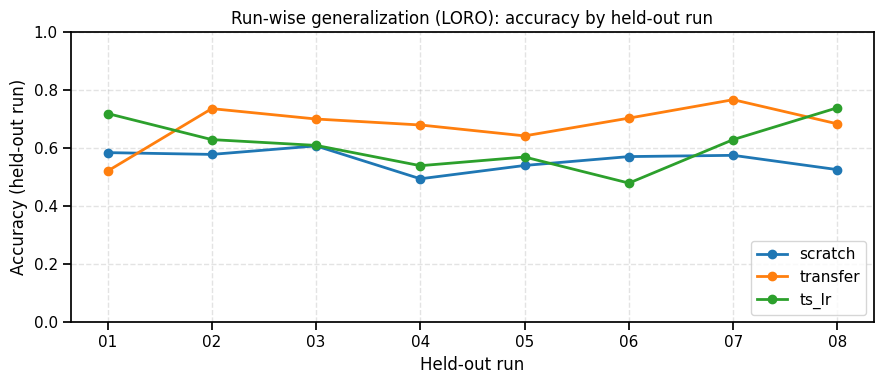

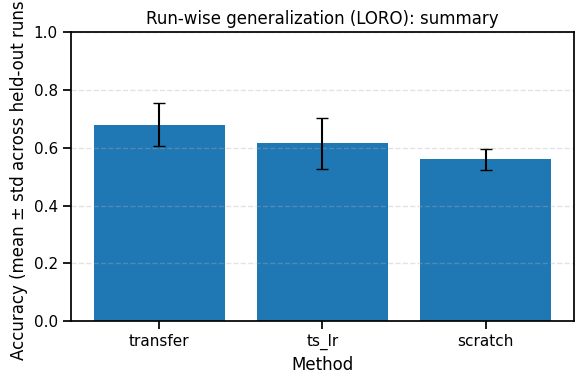

,mode,mean_acc,std_acc,n
1,transfer,0.679799,0.074192,8
2,ts_lr,0.615000,0.087014,8
0,scratch,0.560183,0.036730,8


In [10]:
# Run-wise plots: accuracy by held-out run + mean±std summary

def _parse_note(notes: str, key: str):
    m = re.search(fr"{re.escape(key)}=([^;]+)", str(notes))
    return m.group(1).strip() if m else None


def plot_runwise_loro(metrics_path=METRICS_CSV):
    dfm = pd.read_csv(metrics_path)
    dfm = dfm[dfm['notes'].astype(str).str.contains('split=leave_one_run_out', na=False)].copy()
    if dfm.empty:
        print('No LORO rows found in metrics CSV (split=leave_one_run_out).')
        return

    dfm['test_run'] = dfm['notes'].apply(lambda s: _parse_note(s, 'test_run'))
    dfm['split'] = dfm['notes'].apply(lambda s: _parse_note(s, 'split'))
    dfm['base_model_name'] = dfm['base_model'].astype(str).apply(lambda p: Path(p).name if p and p != 'nan' else '')

    # Keep only the three methods we care about
    dfm = dfm[dfm['mode'].isin(['scratch', 'transfer', 'ts_lr'])]

    # Pivot to wide per run
    pivot = dfm.pivot_table(index='test_run', columns='mode', values='val_accuracy', aggfunc='mean').reset_index()
    pivot = pivot.sort_values('test_run')

    # --- Plot 1: per-run accuracy ---
    plt.figure(figsize=(9, 4))
    for mode, style in [('scratch', '-o'), ('transfer', '-o'), ('ts_lr', '-o')]:
        if mode in pivot.columns:
            plt.plot(pivot['test_run'], pivot[mode], style, linewidth=2, label=mode)
    plt.ylim(0.0, 1.0)
    plt.xlabel('Held-out run')
    plt.ylabel('Accuracy (held-out run)')
    plt.title('Run-wise generalization (LORO): accuracy by held-out run')
    plt.grid(True, linestyle='--', alpha=0.35)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: mean ± std across runs ---
    summary = (
        dfm.groupby('mode')
           .agg(mean_acc=('val_accuracy', 'mean'), std_acc=('val_accuracy', 'std'), n=('val_accuracy', 'size'))
           .reset_index()
           .sort_values('mean_acc', ascending=False)
    )

    plt.figure(figsize=(6, 4))
    plt.bar(summary['mode'], summary['mean_acc'], yerr=summary['std_acc'], capsize=4)
    plt.ylim(0.0, 1.0)
    plt.xlabel('Method')
    plt.ylabel('Accuracy (mean ± std across held-out runs)')
    plt.title('Run-wise generalization (LORO): summary')
    plt.grid(True, axis='y', linestyle='--', alpha=0.35)
    plt.tight_layout()
    plt.show()

    display(summary)


plot_runwise_loro()

## Optional: classical baseline (Riemannian/FB-LDA) command
Run in a terminal (headless-safe):
```
cd /home/connor/LIINC/experiment
python mi_riemann_probe.py --subject 01 --data-dir data --runs 01 02 03 04 05 06 07 08 --tmin 0.5 --tmax 2.0 --group-by-run --sweep
```
This prints MDM/TS+LR/FB-LDA accuracies. If you want plots auto-saved instead of shown, I can patch the script to write PNGs to `results/`.


## Optional: per-run PSD/ERP sanity check
Quick command (pick a representative run):
```
cd /home/connor/LIINC/experiment
python evaluate_mi_data.py data/sub-01_run-03_online_raw.fif --erp --no-browser
```
This will open/save plots interactively; if you want auto-saved PSD/ERP PNGs, I can add a small wrapper to save to `results/`.


## Inline classical baseline & PSD/ERP helpers (no subprocesses)
These helpers import the existing scripts directly so figures display inline.
- `run_classical_inline(...)` uses the functions from `mi_riemann_probe.py` to compute MDM/TS+LR accuracies and plot ERD.
- `show_psd_erp(...)` reuses `evaluate_mi_data.py`'s plotting logic (headless-safe, no interactive browser).

In [11]:
# Imports from analysis scripts
from pipeline.self.mi_riemann_probe import (
    load_epochs_for_subject,
    pick_left_right,
    preprocess,
    crop_and_get_Xy,
    cv_scores_cov_models,
    erd_barplot,
)
from pipeline.self.evaluate_mi_data import plot_summary

# Ensure MNE is quiet
mne.set_log_level('WARNING')


In [12]:
def show_psd_erp(run_path, erp=True, notch=60, l_freq=1.0, h_freq=60.0):
    """Load a single FIF run and display PSD/event timeline and optional ERPs inline."""
    run_path = Path(run_path)
    raw = mne.io.read_raw_fif(str(run_path), preload=True, verbose='ERROR')
    # Apply channel names and montage like evaluate_mi_data.py
    ch_names = ['Fp1', 'Fp2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2', 'F7', 'F8', 'F3', 'F4', 'T7', 'T8', 'P3', 'P4']
    raw.rename_channels(dict(zip(raw.ch_names, ch_names)))
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'))
    raw.notch_filter(notch)
    raw.filter(l_freq, h_freq, fir_design='firwin')
    # Use evaluate_mi_data.plot_summary with browser=False to avoid GUI
    plot_summary(raw, browser=False, erp=erp)


def run_classical_inline(subject='01', runs=None, data_dir=DATA_DIR, tmin=0.5, tmax=2.0, cov_est='lwf', use_csd=True):
    """
    Compute classical baselines (MDM, TS+LR) and plot ERD inline using helpers from mi_riemann_probe.
    Returns a dict of accuracies.
    """
    epochs = load_epochs_for_subject(subject, data_dir, epoch_tmin=-1.0, epoch_tmax=2.5, runs=runs)
    classes = pick_left_right(epochs)
    epochs = preprocess(epochs, use_csd=use_csd)
    ep, X, y = crop_and_get_Xy(epochs, classes, tmin, tmax)
    acc_mdm, acc_ts = cv_scores_cov_models(X, y, cov_est=cov_est)
    print(f"MDM (Riemann): mean={acc_mdm.mean():.3f} std={acc_mdm.std():.3f}")
    print(f"TS+LR        : mean={acc_ts.mean():.3f} std={acc_ts.std():.3f}")
    try:
        erd_barplot(epochs, baseline=(-1.0, 0.0), active=(tmin, tmax), use_csd=use_csd)
    except Exception as e:
        print(f"ERD plot skipped: {e}")
    return {'acc_mdm_mean': acc_mdm.mean(), 'acc_ts_mean': acc_ts.mean(),
            'acc_mdm_std': acc_mdm.std(), 'acc_ts_std': acc_ts.std()}


### Examples (run selectively)
Uncomment and run the next cell to display:
- PSD/ERP for one run (adjust path)
- Classical baseline metrics + ERD plot for your subject/runs

 → Raw duration: 355.2 s


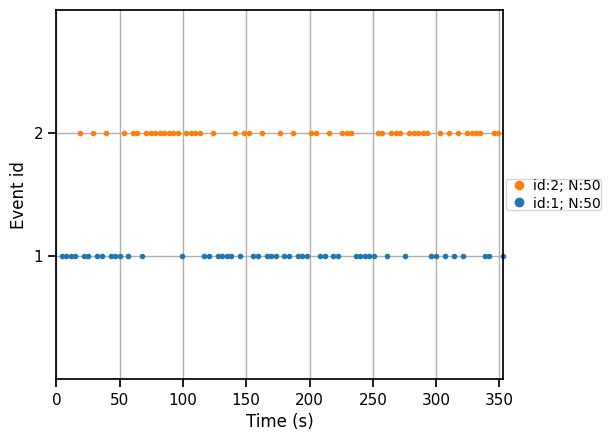

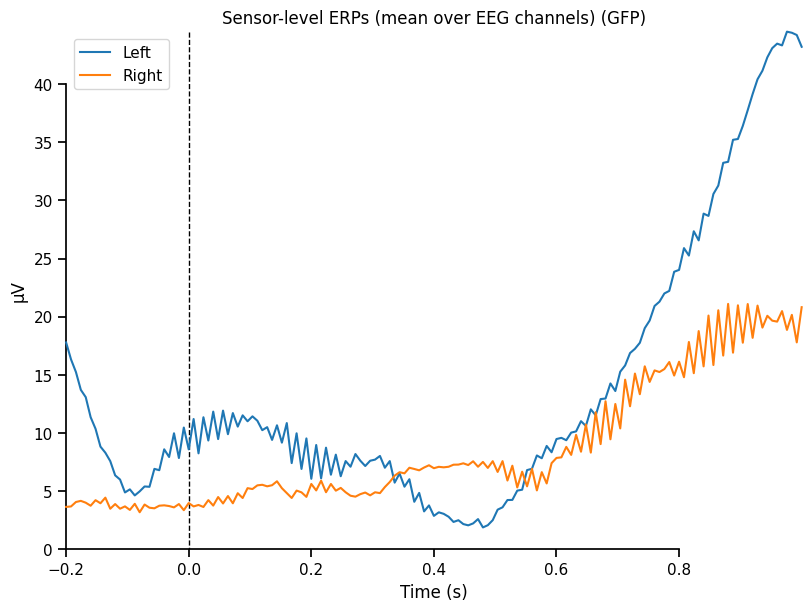

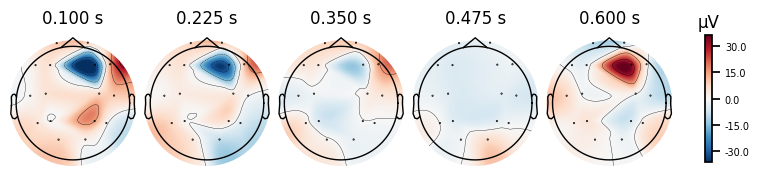

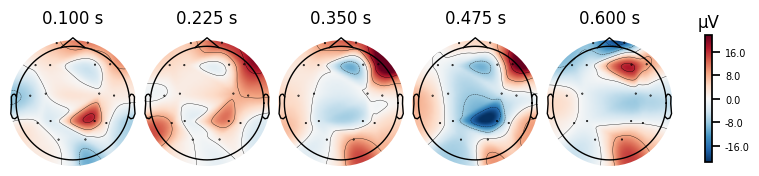

MDM (Riemann): mean=0.506 std=0.044
TS+LR        : mean=0.625 std=0.027


{'acc_mdm_mean': np.float64(0.5059330948874395),
 'acc_ts_mean': np.float64(0.6250157795076794),
 'acc_mdm_std': np.float64(0.04416115615748626),
 'acc_ts_std': np.float64(0.027050541846552652)}

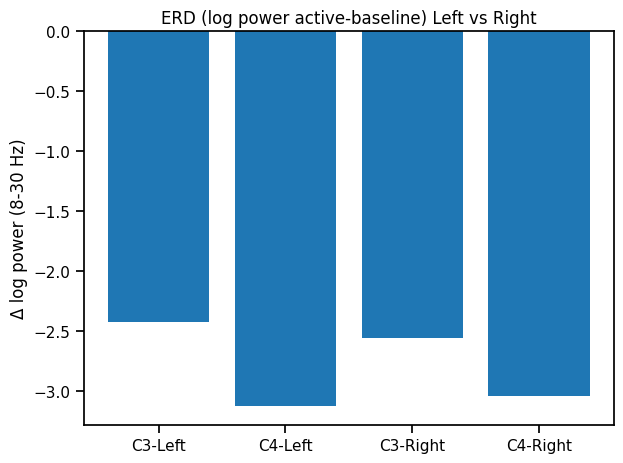

In [13]:
# Example usage (uncomment to run)
show_psd_erp(DATA_DIR / 'sub-01_run-03_online_raw.fif', erp=True)
run_classical_inline(subject='01', runs=['01','02','03','04','05','06','07','08'], tmin=0.5, tmax=2.0)


## Extra: quantify uncertainty + ablations + repeatability

These sections make the project stronger:
- **Bootstrap CI** on accuracy for a fixed evaluation split.
- **Ablations**: raw-only vs CSP-only vs full model.
- **Repeatability**: rerun training with multiple seeds to get mean±std (optional; can take time).

In [14]:
from sklearn.metrics import accuracy_score

def bootstrap_ci_accuracy(y_true, y_pred, n_boot=2000, seed=0):
    """Bootstrap CI for accuracy."""
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    accs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        accs.append(accuracy_score(y_true[idx], y_pred[idx]))
    accs = np.asarray(accs)
    return float(accs.mean()), (float(np.quantile(accs, 0.025)), float(np.quantile(accs, 0.975)))


def evaluate_model_with_preds(model_path, runs, subject='01', val_split=0.2, seed=42, ablation='full'):
    """
    ablation:
      - 'full'     : raw + features
      - 'raw_only' : raw only
      - 'csp_only' : CSP features only (raw input zeroed)
    """
    X, y, idx, _, _run_id = load_runs(subject=subject, runs=runs)
    X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
        X, y, idx, test_size=val_split, stratify=y, random_state=seed
    )
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.long, device=device)
    idx_val_t = torch.tensor(idx_val, dtype=torch.long, device=device)

    clf, _ = HybridModelClassifier.load_model(str(model_path), device=device)
    target_channels = getattr(clf.model, 'n_channels', X_val_t.shape[1])
    X_val_t = match_channels(X_val_t, target_channels)

    # Ensure feature modules exist if needed
    has_fm = hasattr(clf, 'feature_modules') and bool(getattr(clf, 'feature_modules', None))

    if ablation == 'raw_only':
        clf.use_feature_modules = False
    elif ablation == 'csp_only':
        if not has_fm:
            raise ValueError('Model does not have saved feature modules; cannot run csp_only ablation.')
        clf.use_feature_modules = True
        X_val_t = torch.zeros_like(X_val_t)  # zero raw branch
    elif ablation == 'full':
        clf.use_feature_modules = bool(has_fm)
    else:
        raise ValueError(f'Unknown ablation: {ablation}')

    res = clf.evaluate(X_val_t, y_val_t, subject_indices=idx_val_t)
    return res


In [15]:
# Bootstrap CI + ablations on best transfer model (adjust model path)
BEST_TRANSFER = MODELS_DIR / 'offline_transfer' / 'offline_transfer.pt'
RUNS = ['01','02','03','04','05','06','07','08']

if BEST_TRANSFER.exists():
    res_full = evaluate_model_with_preds(BEST_TRANSFER, RUNS, ablation='full')
    mean_acc, (lo, hi) = bootstrap_ci_accuracy(res_full['targets'], res_full['predictions'], n_boot=2000, seed=0)
    print(f"Transfer(full) accuracy={res_full['accuracy']:.4f}; bootstrap 95% CI [{lo:.3f}, {hi:.3f}] (mean={mean_acc:.3f})")

    # Ablations
    for ab in ['raw_only', 'csp_only']:
        try:
            r = evaluate_model_with_preds(BEST_TRANSFER, RUNS, ablation=ab)
            print(f"Transfer({ab}) accuracy={r['accuracy']:.4f}")
        except Exception as e:
            print(f"Transfer({ab}) skipped: {e}")
else:
    print('Missing transfer model at', BEST_TRANSFER)


Transfer(full) accuracy=0.6387; bootstrap 95% CI [0.561, 0.716] (mean=0.638)
Transfer(raw_only) accuracy=0.5742
Transfer(csp_only) accuracy=0.5032


## Optional: repeatability sweep (multiple seeds)

This re-runs training for a few seeds so you can report **mean ± std** instead of single-run numbers.

- Set `RUN_SEED_SWEEP=True` and run the next cell.
- It will append to `results/offline_metrics.csv`, so your learning curve plots automatically update.

In [16]:
RUN_SEED_SWEEP = False  # set True to execute
SEEDS = [0, 1, 2]
RUN_SETS = [
    ['01','02'],
    ['01','02','03','04'],
    ['01','02','03','04','05','06','07','08'],
]
BASE_MODEL = REPO_ROOT / "legacy" / "model" / "models" / "base_model_90_subjects.pt"

seed_cmds = []
for seed in SEEDS:
    for runs in RUN_SETS:
        run_str = ' '.join(runs)
        tag = f"r{len(runs)}_s{seed}"
        seed_cmds.append(
            f"python -m pipeline.self.train --data-dir data/self --runs {run_str} --seed {seed} "
            f"--model-name offline_scratch_{tag} --output-dir runs/self/models/offline_scratch_{tag} "
            f"--metrics-csv runs/self/results/offline_metrics.csv"
        )
        seed_cmds.append(
            f"python -m pipeline.self.train --data-dir data/self --runs {run_str} --seed {seed} "
            f"--base-model-path {BASE_MODEL} "
            f"--model-name offline_transfer_{tag} --output-dir runs/self/models/offline_transfer_{tag} "
            f"--metrics-csv runs/self/results/offline_metrics.csv"
        )

print(f"Planned {len(seed_cmds)} commands (set RUN_SEED_SWEEP=True to run).")
print('\n'.join(seed_cmds[:6]) + ('\n...' if len(seed_cmds) > 6 else ''))

if RUN_SEED_SWEEP:
    for c in seed_cmds:
        print(f"\nRunning: {c}")
        proc = subprocess.run(shlex.split(c), cwd=REPO_ROOT, env={**os.environ, 'PYGLET_HEADLESS': 'True'})
        if proc.returncode != 0:
            print(f"Command failed: {c}")
            break


Planned 18 commands (set RUN_SEED_SWEEP=True to run).
python -m pipeline.self.train --data-dir data/self --runs 01 02 --seed 0 --model-name offline_scratch_r2_s0 --output-dir runs/self/models/offline_scratch_r2_s0 --metrics-csv runs/self/results/offline_metrics.csv
python -m pipeline.self.train --data-dir data/self --runs 01 02 --seed 0 --base-model-path /home/connor/LIINC/eeg-motor-classification/legacy/model/models/base_model_90_subjects.pt --model-name offline_transfer_r2_s0 --output-dir runs/self/models/offline_transfer_r2_s0 --metrics-csv runs/self/results/offline_metrics.csv
python -m pipeline.self.train --data-dir data/self --runs 01 02 03 04 --seed 0 --model-name offline_scratch_r4_s0 --output-dir runs/self/models/offline_scratch_r4_s0 --metrics-csv runs/self/results/offline_metrics.csv
python -m pipeline.self.train --data-dir data/self --runs 01 02 03 04 --seed 0 --base-model-path /home/connor/LIINC/eeg-motor-classification/legacy/model/models/base_model_90_subjects.pt --model